In [ ]:
!pip install shap

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score
)
import shap

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

cols_to_drop = ["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

print("Dataset Shape:",df.shape)
print(df.info)
print("\nFirst 5 rows\n",df.head())
print("\nMissing Values:\n")
print(df.isnull().sum())

Dataset Shape: (1470, 31)
<bound method DataFrame.info of       Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
...   ...       ...                ...        ...                     ...   
1465   36        No  Travel_Frequently        884  Research & Development   
1466   39        No      Travel_Rarely        613  Research & Development   
1467   27        No      Travel_Rarely        155  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      DistanceFro

/tmp/ipykernel_488/3197661275.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Attrition", palette="Set2")


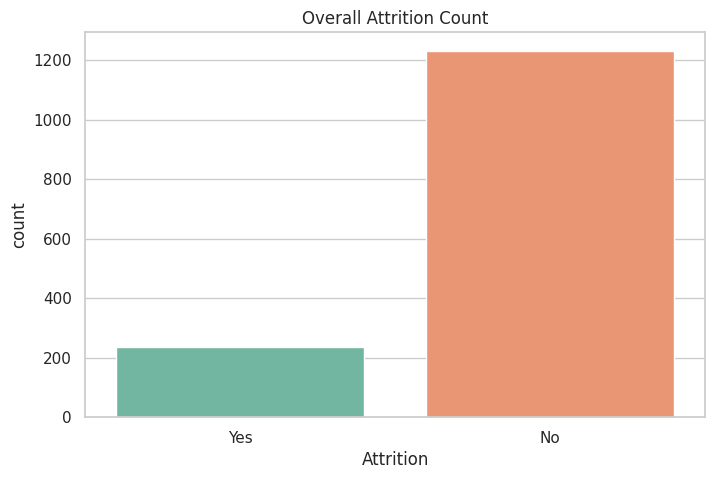

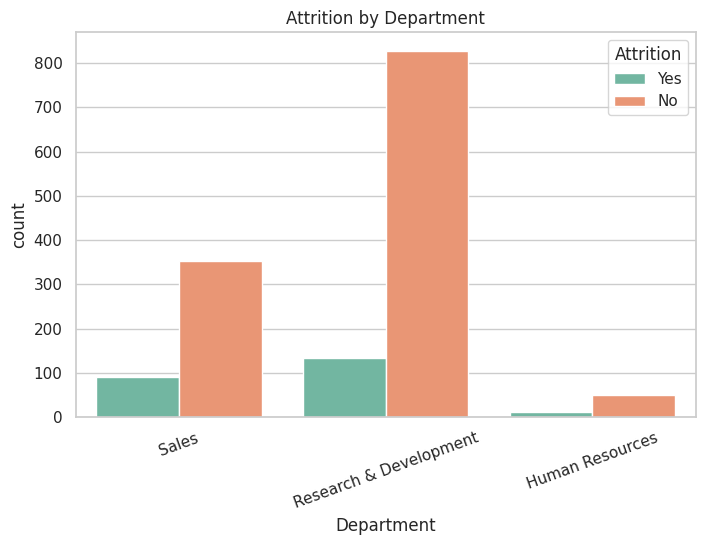

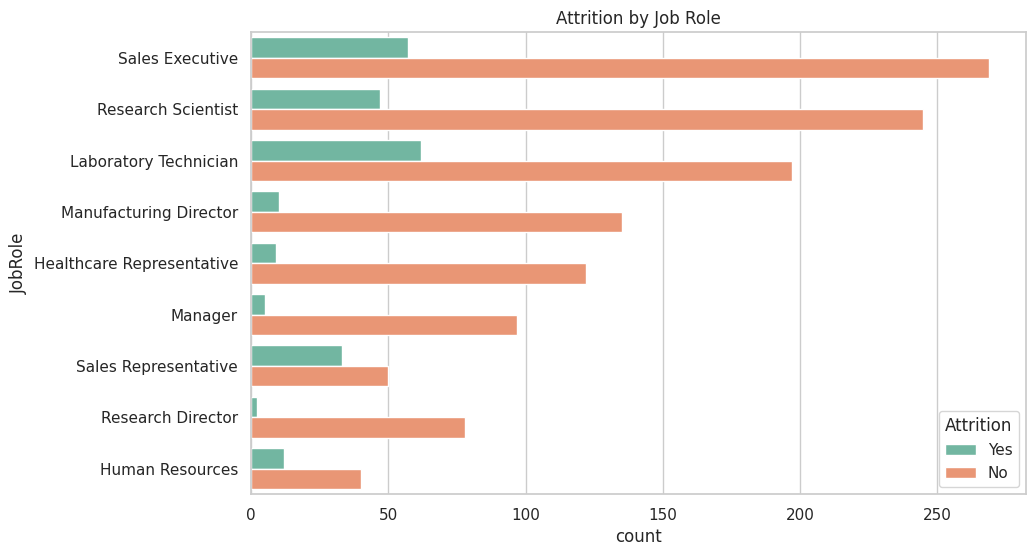

/tmp/ipykernel_488/3197661275.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", palette="Set2")


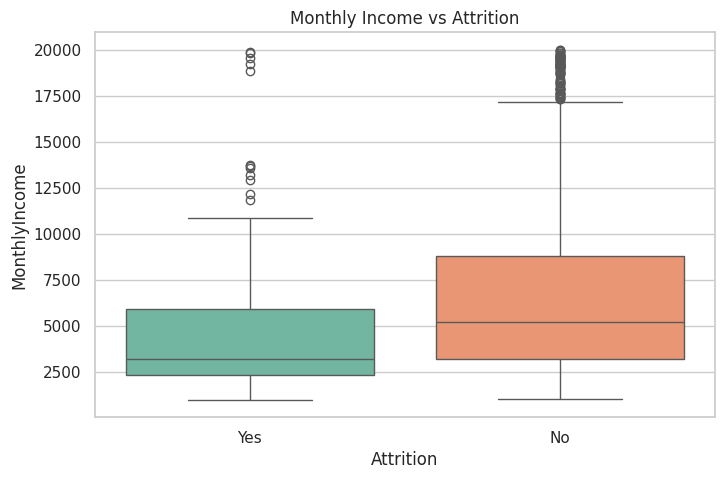

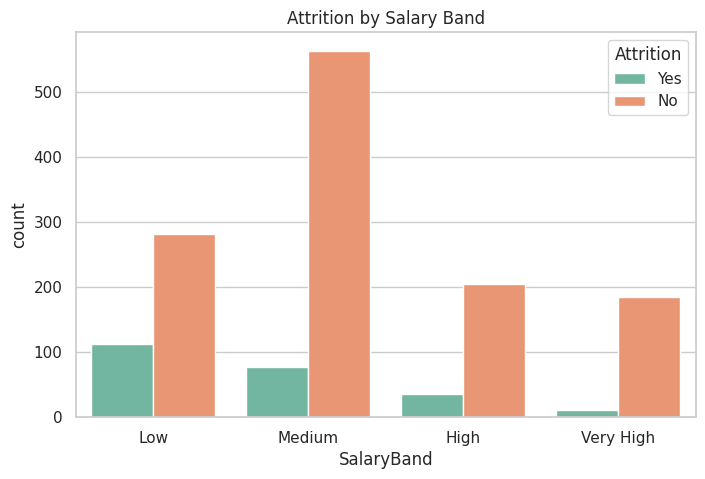

/tmp/ipykernel_488/3197661275.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


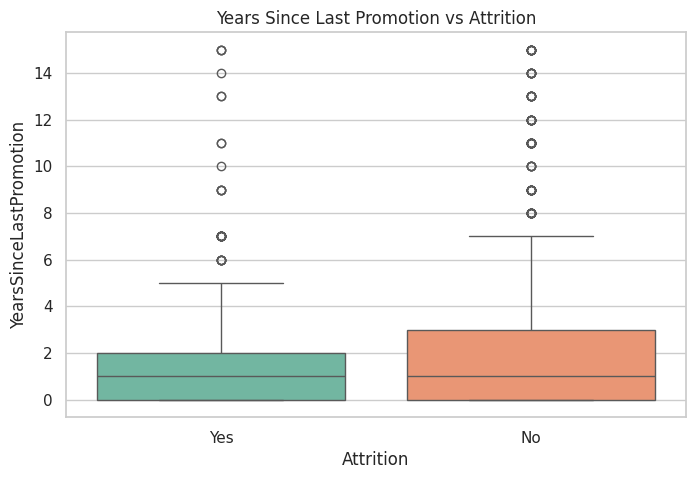

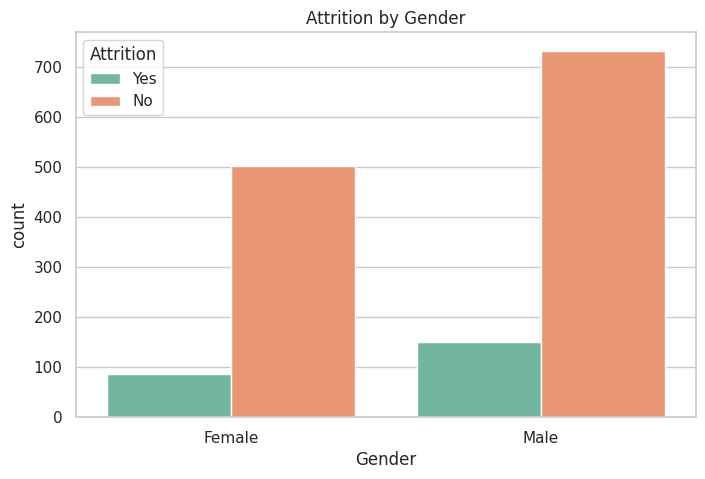

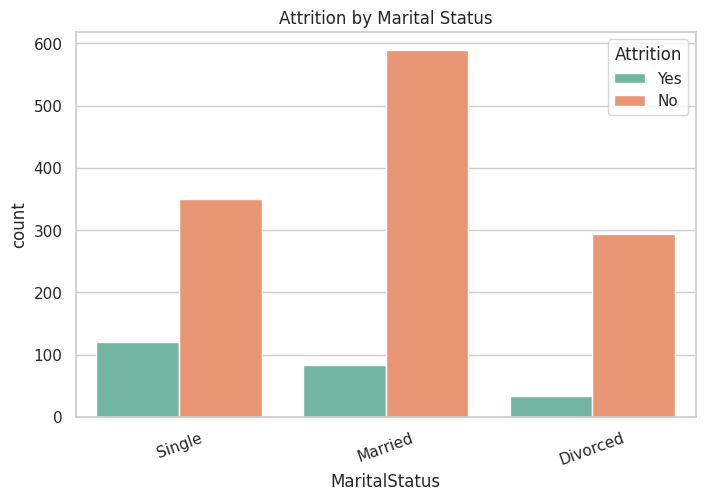

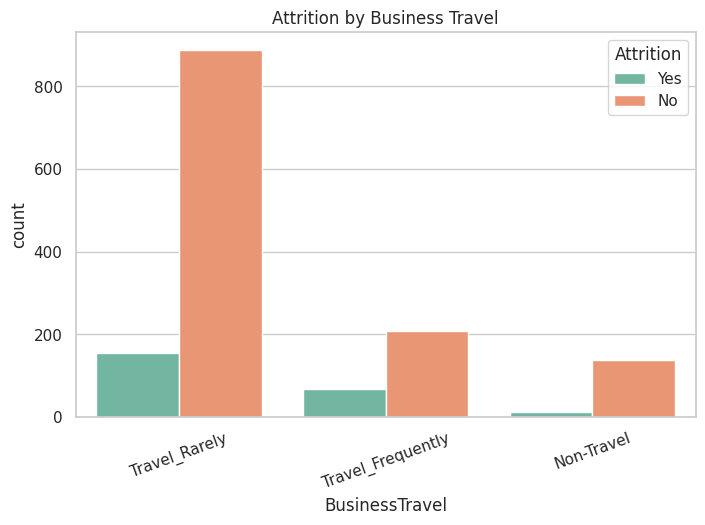

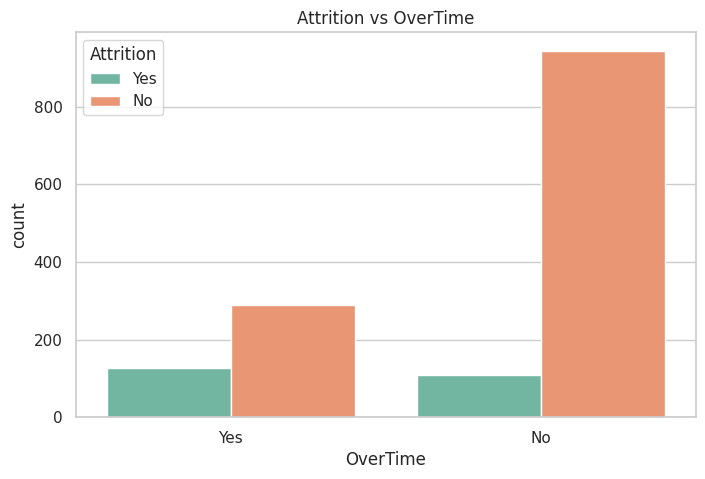

In [ ]:
plt.figure()
sns.countplot(data=df, x="Attrition", palette="Set2")
plt.title("Overall Attrition Count")
plt.show()
print("\n")

plt.figure()
sns.countplot(data=df, x="Department", hue="Attrition", palette="Set2")
plt.title("Attrition by Department")
plt.xticks(rotation=20)
plt.show()
print("\n")

plt.figure(figsize=(10,6))
sns.countplot(data=df, y="JobRole", hue="Attrition", palette="Set2")
plt.title("Attrition by Job Role")
plt.show()
print("\n")

plt.figure()
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", palette="Set2")
plt.title("Monthly Income vs Attrition")
plt.show()
print("\n")

df["SalaryBand"] = pd.cut(
    df["MonthlyIncome"],
    bins=[0,3000,7000,12000,25000],
    labels=["Low","Medium","High","Very High"]
)

plt.figure()
sns.countplot(data=df, x="SalaryBand", hue="Attrition", palette="Set2")
plt.title("Attrition by Salary Band")
plt.show()
print("\n")

plt.figure()
sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsSinceLastPromotion",
    palette="Set2"
)
plt.title("Years Since Last Promotion vs Attrition")
plt.show()
print("\n")

plt.figure()
sns.countplot(
    data=df,
    x="Gender",
    hue="Attrition",
    palette="Set2"
)
plt.title("Attrition by Gender")
plt.show()
print("\n")

plt.figure()
sns.countplot(
    data=df,
    x="MaritalStatus",
    hue="Attrition",
    palette="Set2"
)
plt.title("Attrition by Marital Status")
plt.xticks(rotation=20)
plt.show()
print("\n")

plt.figure()
sns.countplot(
    data=df,
    x="BusinessTravel",
    hue="Attrition",
    palette="Set2"
)
plt.title("Attrition by Business Travel")
plt.xticks(rotation=20)
plt.show()
print("\n")

plt.figure()
sns.countplot(data=df, x="OverTime", hue="Attrition", palette="Set2")
plt.title("Attrition vs OverTime")
plt.show()
print("\n")

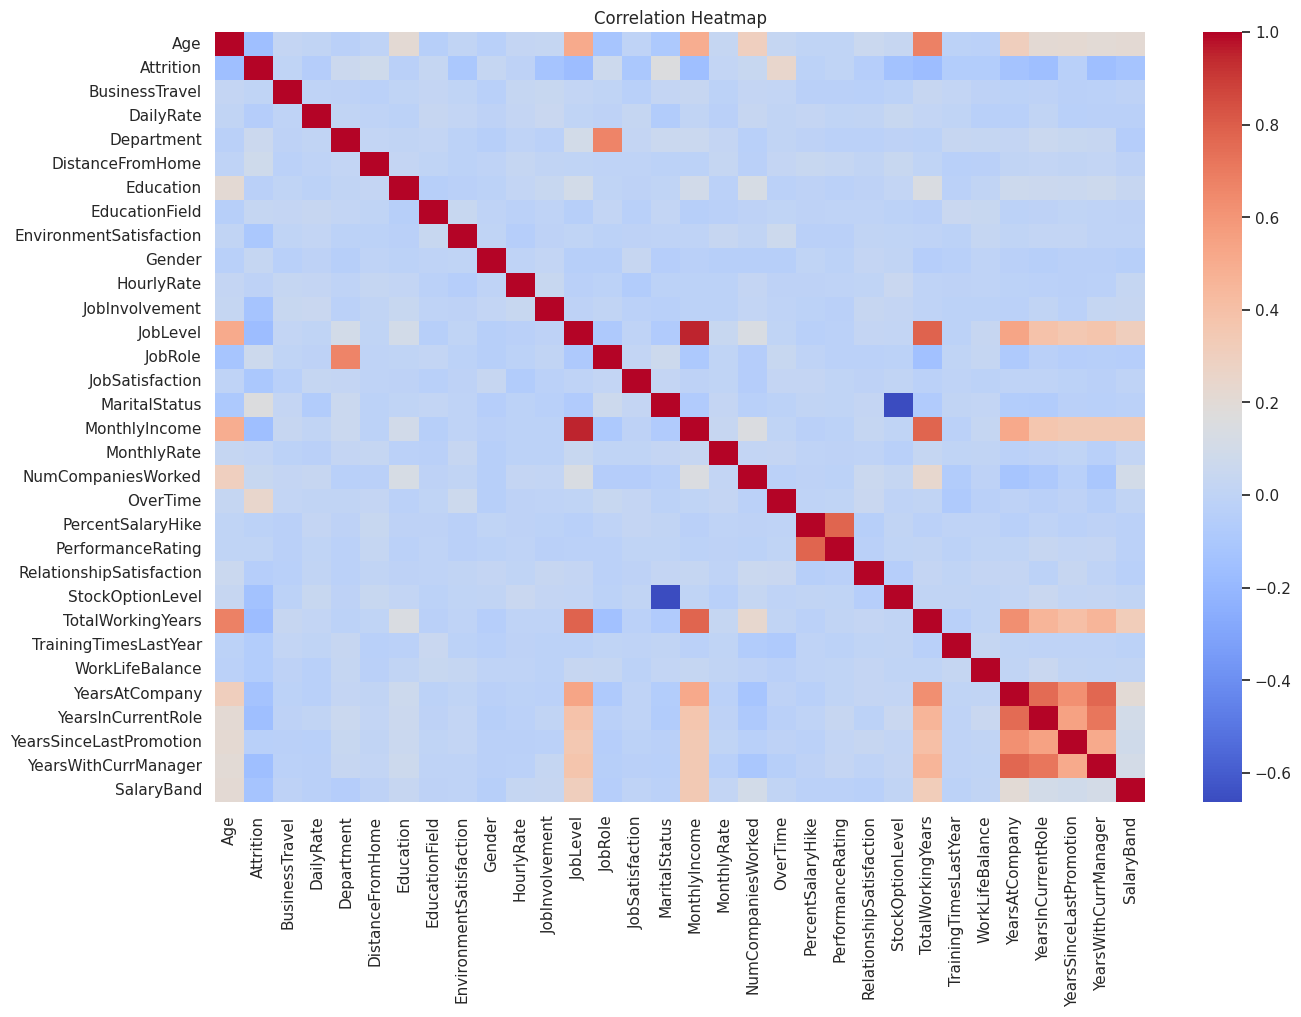

Missing in y: 0


In [ ]:
df_model = df.copy()

df_model["Attrition"] = df_model["Attrition"].map({"Yes": 1, "No": 0})

categorical_cols = df_model.select_dtypes(include=["object", "category"]).columns.tolist()
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
plt.figure(figsize=(15,10))
sns.heatmap(
    df_model.corr(),
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

X = df_model.drop("Attrition", axis=1)
y = df_model["Attrition"]

print("Missing in y:", y.isnull().sum())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Accuracy: 0.7414965986394558
Precision: 0.3592233009708738
Recall: 0.7872340425531915
F1: 0.49333333333333335
ROC-AUC: 0.8358170385046085

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.73      0.83       247
           1       0.36      0.79      0.49        47

    accuracy                           0.74       294
   macro avg       0.65      0.76      0.66       294
weighted avg       0.85      0.74      0.77       294



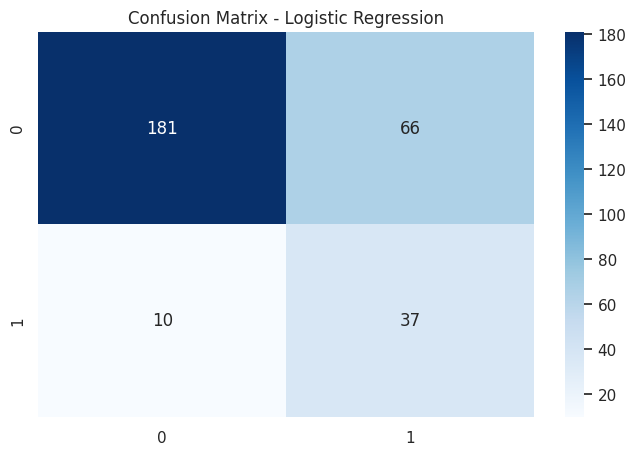

In [ ]:
log_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_model.fit(X_train_scaled, y_train)
log_preds = log_model.predict(X_test_scaled)
log_probs = log_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, log_preds))
print("Precision:", precision_score(y_test, log_preds))
print("Recall:", recall_score(y_test, log_preds))
print("F1:", f1_score(y_test, log_preds))
print("ROC-AUC:", roc_auc_score(y_test, log_probs))
print("\nClassification Report:")
print(classification_report(y_test, log_preds))

cm_log = confusion_matrix(y_test, log_preds)
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Accuracy: 0.7414965986394558
Precision: 0.32098765432098764
Recall: 0.5531914893617021
F1: 0.40625
ROC-AUC: 0.6440692566112499

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.78      0.83       247
           1       0.32      0.55      0.41        47

    accuracy                           0.74       294
   macro avg       0.61      0.67      0.62       294
weighted avg       0.81      0.74      0.77       294



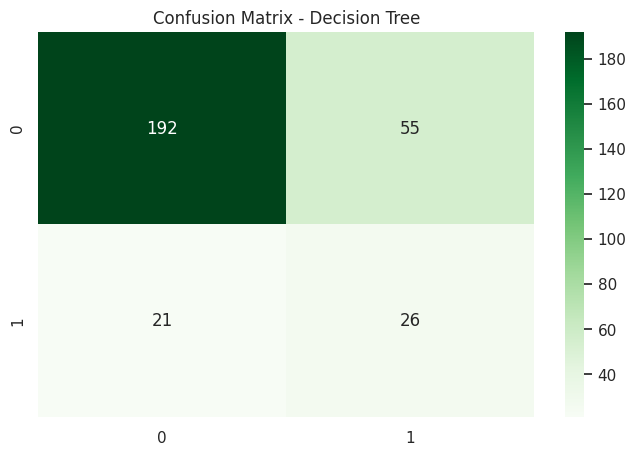

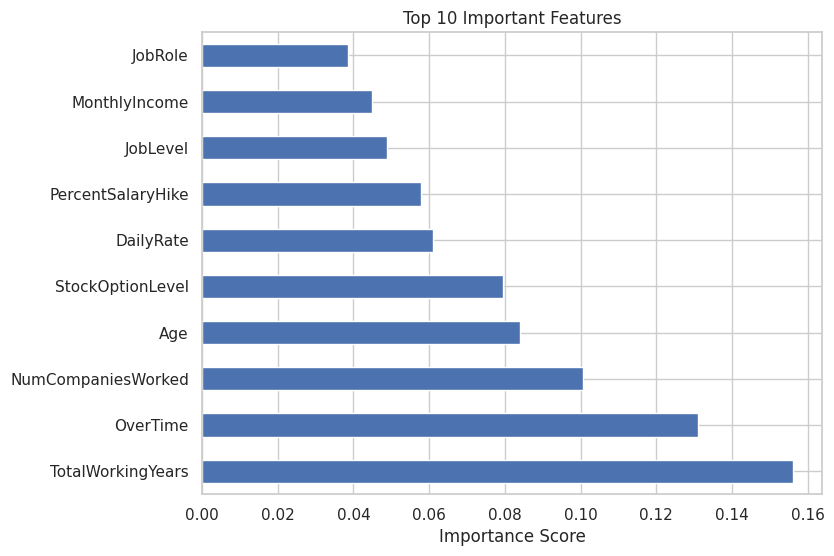

In [ ]:
tree_model = DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42)
tree_model.fit(X_train, y_train)
tree_preds = tree_model.predict(X_test)
tree_probs = tree_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, tree_preds))
print("Precision:", precision_score(y_test, tree_preds))
print("Recall:", recall_score(y_test, tree_preds))
print("F1:", f1_score(y_test, tree_preds))
print("ROC-AUC:", roc_auc_score(y_test, tree_probs))
print("\nClassification Report:")
print(classification_report(y_test, tree_preds))

cm_tree = confusion_matrix(y_test, tree_preds)
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Decision Tree")
plt.show()
print("\n")

importance = pd.Series(
    tree_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importance.head(10).plot(kind="barh")
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.show()

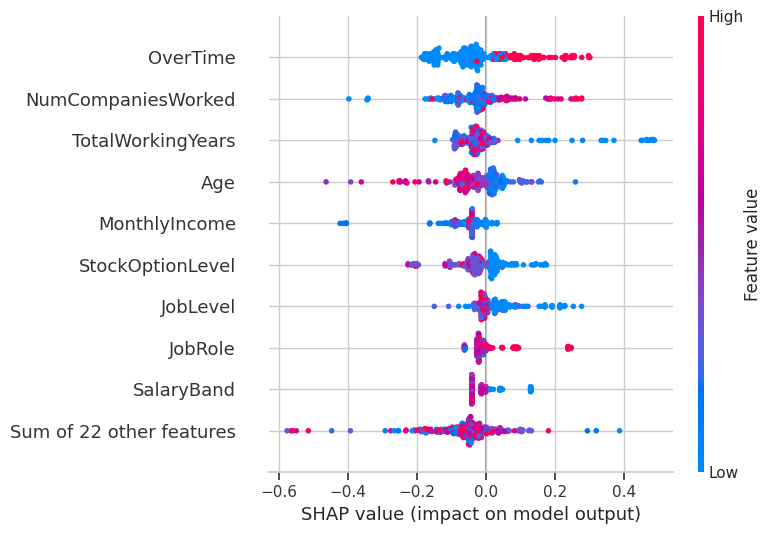

In [ ]:
import matplotlib.pyplot as plt
import shap
explainer = shap.TreeExplainer(tree_model)
shap_values = explainer(X_test)
if len(shap_values.shape) == 3:
    values_to_plot = shap_values[:, :, 1]
else:
    values_to_plot = shap_values
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(values_to_plot, max_display=10, show=False)
plt.tight_layout()
plt.show()